# Correlation between scRNA-seq data and DCM labels

This notebook compares single-cell RNA-seq data from iPSCs, definitive endoderm (DE), and primitive gut tube (PGT) cells to MeD-seq data of DCM labels with various pulse and isolation points.

## Input 

- Scanpy object generated in notebook 6 (scRNA.h5ad)
- List of DEGs generated in notebook 8 (SupplementalTable3.txt)
- DCM scores per gene, available from GEO (GSE304236_DCMscores.genes.txt)
- RNA expression in TPM, available from GEO (GSE304232_iPSCs.RNA-seq.TPMs.txt)

## Output

- Figure 2g: Correlation DCM dox to scRNA and RNA data
- Figure 2h: Correlation DCM chase to DCM dox
- Figure S5f: Correlation DCM dox on scRNA-seq layout
- Figure S5g: Correlation DCM chase on scRNA-seq layout

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import median_abs_deviation, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# scRNA-seq analysis
import warnings
warnings.simplefilter("ignore", category=(UserWarning, FutureWarning, DeprecationWarning))
import scanpy as sc

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sc.set_figure_params(format="svg", dpi_save=300, figsize=(10,10), vector_friendly=False)
sns.set_style("ticks")

# Versions
sc.logging.print_versions()

-----
anndata     0.11.4
scanpy      1.10.3
-----
PIL                         10.4.0
anyio                       NA
argcomplete                 NA
arrow                       1.4.0
asttokens                   NA
attr                        25.4.0
attrs                       25.4.0
babel                       2.16.0
brotli                      1.2.0
certifi                     2026.02.25
cffi                        2.0.0
charset_normalizer          3.3.2
colorama                    0.4.6
comm                        0.2.3
cycler                      0.12.1
cython_runtime              NA
dateutil                    2.9.0.post0
debugpy                     1.8.17
decorator                   5.2.1
defusedxml                  0.7.1
exceptiongroup              1.2.2
executing                   2.2.1
fastjsonschema              NA
fqdn                        NA
h5py                        3.12.1
idna                        3.11
ipykernel                   6.26.0
ipywidgets                  8.1.

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)
sc.settings.figdir = output_dir

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

## Merge bulk RNA, scRNA-seq and DCM-TM datasets

In [3]:
# Load RNA-seq counts
rna = pd.read_csv(f"{input_dir}/GSE304232_iPSCs.RNA-seq.TPMs.txt", sep="\t", header=0, index_col=None)
rna["RNA"] = rna[[f"iPSCs.dox.{i}" for i in (1,2,3)] + [f"iPSCs.nodox.{i}" for i in (1,2,3)]].mean(axis=1)
rna.index = rna["GeneName"]
display(rna)

,GeneID,GeneName,iPSCs.dox.1,iPSCs.dox.2,iPSCs.dox.3,iPSCs.nodox.1,iPSCs.nodox.2,iPSCs.nodox.3,RNA
GeneName,,,,,,,,,
ATAD3B,ENSG00000160072,ATAD3B,21.421537,20.158241,22.926484,21.001731,18.968171,31.913003,22.731528
DDX11L17,ENSG00000279928,DDX11L17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
NaN,ENSG00000228037,NaN,0.283725,0.000000,0.000000,0.000000,0.000000,0.000000,0.047287
PRDM16,ENSG00000142611,PRDM16,0.418252,0.637932,0.736009,0.582045,0.682093,0.640537,0.616145
NaN,ENSG00000284616,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
NaN,ENSG00000271254,NaN,4.055437,3.580850,3.951009,3.590141,3.609745,3.618932,3.734352
U1,ENSG00000275987,U1,0.616707,0.000000,0.000000,1.038895,1.075904,2.996230,0.954623
NaN,ENSG00000268674,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


AnnData object with n_obs × n_vars = 1022 × 36693
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts-DE', 'mean_counts-DE', 'log1p_mean_counts-DE', 'pct_dropout_by_counts-DE', 'total_counts-DE', 'log1p_total_counts-DE', 'n_cells_by_counts-PGT', 'mean_counts-PGT', 'log1p_mean_counts-PGT', 'pct_dropout_by_counts-PGT', 'total_counts-PGT', 'log1p_total_counts-PGT', 'n_cells_by_counts-iPSC', 'mean_counts-iPSC', 'log1p_mean_counts-iPSC', 'pct_dropout_by_counts-iPSC', 'total_counts-iPSC', 'log1p_total_counts-iPSC', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Celltype', 'Celltype_colors', 'hvg', 'log1p', 'neighbors', 'pca'
    obsm: 'Harmo

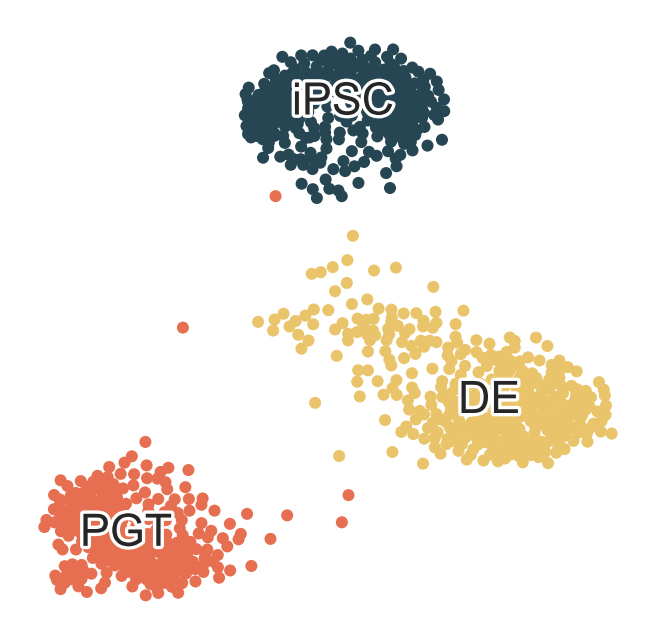

In [4]:
# Load scRNA-seq dataset
adata = sc.read_h5ad(f"{output_dir}/scRNA.h5ad")
print(adata)

with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.embedding(adata, basis="Harmony", frameon=False, color="Celltype", palette=palette, title="",
                    legend_loc="on data", legend_fontsize="x-large", legend_fontweight="normal", legend_fontoutline=3, show=True)

In [5]:
# Mean scRNA-seq expression per cell type
avg_counts = pd.DataFrame(adata.layers["CPM"].toarray(), index=adata.obs.index, columns=adata.var_names)
avg_counts["Celltype"] = adata.obs["Celltype"].values
avg_counts = avg_counts.groupby("Celltype").mean().T
display(avg_counts)

Celltype,iPSC,DE,PGT
MIR1302-2HG,0.000000,0.000000,0.000000
FAM138A,0.000000,0.000000,0.000000
OR4F5,0.000000,0.000000,0.000000
AL627309.1,0.205345,0.833383,0.771237
AL627309.3,0.000000,0.000000,0.000000
...,...,...,...
ERCC-00164,0.418747,0.966150,0.000000
ERCC-00165,5.759097,8.477218,10.424499
ERCC-00168,0.126652,0.641207,0.451892
ERCC-00170,2.636265,5.623537,4.560140


In [6]:
# DCM scores
dcm = pd.read_csv(f"{input_dir}/GSE304236_DCMscores.genes.txt", sep="\t", index_col=0, header=0)
dcm = dcm[dcm["NrSites"] > 10]
dcm = dcm[dcm["GeneName"] != "."]
dcm.index = dcm["GeneName"]
display(dcm)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,C6neg-1,C6neg-2,C6neg-3,C6-1,...,T48,T72,iPSC_nodox,iPSC_chase,iPSC_dox,DE_chase,DE_dox,PGT_chase,GeneName,NrSites
GeneName,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000620,0.001612,0.003014,0.042822,0.039482,0.048462,0.001442,0.000000,0.000000,0.046142,...,0.000000,0.000000,0.001749,0.006315,0.043589,0.018845,0.048050,0.012696,TSPAN6,38
TNMD,0.000575,0.000000,0.000000,0.038807,0.034341,0.040833,0.000000,0.001415,0.000705,0.033411,...,0.039010,0.000000,0.000192,0.003627,0.037994,0.008884,0.023858,0.005416,TNMD,41
DPM1,0.004438,0.005045,0.002021,0.103165,0.083093,0.087647,0.004512,0.002730,0.003061,0.086059,...,0.018816,0.000000,0.003835,0.032069,0.091302,0.045974,0.055403,0.055444,DPM1,85
SCYL3,0.001331,0.003211,0.002309,0.051179,0.057704,0.045904,0.002651,0.002339,0.003963,0.047282,...,0.000000,0.000000,0.002284,0.014743,0.051596,0.023948,0.051521,0.034199,SCYL3,124
C1orf112,0.001804,0.002180,0.002140,0.035357,0.040372,0.042450,0.002047,0.001703,0.002777,0.037439,...,0.005692,0.015669,0.002041,0.013985,0.039393,0.022678,0.036709,0.026909,C1orf112,562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMG1P7,0.047153,0.019692,0.024539,0.138187,0.089029,0.091680,0.041089,0.018646,0.010324,0.103718,...,0.429924,0.000000,0.030462,0.177051,0.106298,0.147911,0.069065,0.100861,SMG1P7,14
SMG1P5,0.002655,0.004829,0.004256,0.094638,0.090974,0.089112,0.003702,0.001698,0.003646,0.091200,...,0.048726,0.000000,0.003913,0.030101,0.091575,0.046383,0.075609,0.060821,SMG1P5,222
ANKRD20A11P,0.005164,0.001167,0.002999,0.017392,0.019784,0.017539,0.001826,0.004144,0.004680,0.020352,...,0.000000,0.000000,0.003110,0.030013,0.018238,0.031264,0.023170,0.027319,ANKRD20A11P,105


In [7]:
# scRNA-seq DEGs
degs = pd.read_csv(f"{output_dir}/SupplementalTable3.txt", sep="\t")
degs = degs[(degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 1)]
display(degs)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,iPSC,SFRP2,26.595260,8.284877,7.701220e-156,1.507187e-151
1,iPSC,ERVH-1,26.592836,8.634070,8.215121e-156,1.507187e-151
2,iPSC,DNMT3B,26.526022,3.846034,4.857166e-155,5.940800e-151
3,iPSC,TERF1,26.514334,3.496398,6.624909e-155,6.077194e-151
4,iPSC,SOX2,26.330430,8.206783,8.600517e-153,5.259646e-149
...,...,...,...,...,...,...
76496,PGT,TMEM8B,3.242991,1.104018,1.182821e-03,9.053244e-03
76508,PGT,NPC1L1,3.233302,4.781400,1.223683e-03,9.334844e-03
76509,PGT,GRHL3,3.231057,4.554933,1.233335e-03,9.404565e-03
76521,PGT,SOD3,3.222076,2.485342,1.272651e-03,9.668199e-03


In [8]:
deg_counts = avg_counts.merge(dcm, left_index=True, right_index=True)
deg_counts = deg_counts.merge(rna, left_index=True, right_index=True)
deg_counts = deg_counts[deg_counts.index.isin(degs["names"])]
display(deg_counts)

,iPSC,DE,PGT,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,C6neg-1,...,NrSites,GeneID,GeneName_y,iPSCs.dox.1,iPSCs.dox.2,iPSCs.dox.3,iPSCs.nodox.1,iPSCs.nodox.2,iPSCs.nodox.3,RNA
LINC01128,7.218008,14.435974,25.901432,0.005125,0.009133,0.011203,0.047840,0.045590,0.046620,0.006295,...,161,ENSG00000228794,LINC01128,1.473668,1.584444,1.570411,1.616136,1.630572,1.621748,1.582830
SAMD11,1.968089,16.913071,51.059952,0.024597,0.016936,0.022848,0.074321,0.059479,0.057012,0.025285,...,208,ENSG00000187634,SAMD11,0.085145,0.298690,0.265086,0.251008,0.111407,0.361961,0.228883
NOC2L,190.168839,102.717773,96.135231,0.030785,0.020486,0.023341,0.085335,0.065716,0.059715,0.031754,...,157,ENSG00000188976,NOC2L,120.208414,106.318941,121.639989,116.305200,138.038932,188.704053,131.869255
AGRN,6.804227,10.568459,21.574539,0.036775,0.024889,0.025984,0.130494,0.084110,0.080978,0.043024,...,368,ENSG00000188157,AGRN,63.701504,55.507342,67.470402,44.459017,53.673446,49.256110,55.677970
ACAP3,9.804241,11.678169,26.768818,0.041081,0.024598,0.032533,0.143366,0.094541,0.094277,0.044271,...,198,ENSG00000131584,ACAP3,19.460370,17.484355,21.846964,15.910230,15.249250,20.564452,18.419270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F8A1,24.028301,6.401131,11.711671,0.003144,0.006126,0.007634,0.107278,0.096942,0.078127,0.000000,...,15,ENSG00000288722,F8A1,2.965395,2.798392,3.563365,2.366270,3.630469,5.181529,3.417570
BRCC3,19.404144,15.335999,46.104382,0.001715,0.001114,0.001562,0.027285,0.036091,0.036527,0.000498,...,110,ENSG00000185515,BRCC3,38.203880,40.475147,33.534476,45.929253,39.686806,37.953503,39.297177
ZFY,12.058916,24.939514,49.284828,0.002751,0.000511,0.001431,0.045955,0.047125,0.052085,0.000685,...,120,ENSG00000067646,ZFY,6.168622,4.933416,4.875924,6.272628,6.161523,4.503241,5.485892
NLGN4Y,24.129877,9.703569,38.534801,0.001335,0.001464,0.001260,0.037116,0.053886,0.050575,0.001137,...,795,ENSG00000165246,NLGN4Y,14.458198,14.380909,13.234889,16.469498,15.559735,12.828730,14.488660


## Figure 2g: Correlation DCM dox to scRNA and RNA data

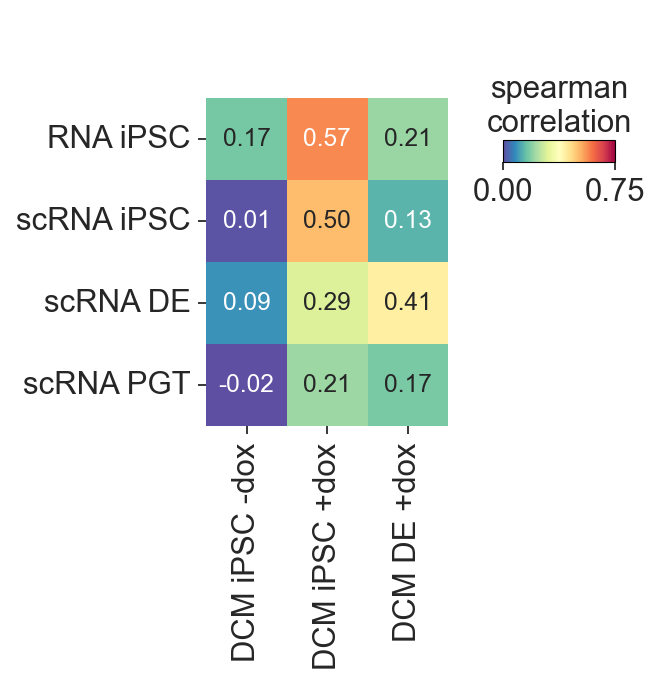

In [9]:
corr_counts = deg_counts[["RNA", "iPSC", "DE", "PGT", "iPSC_nodox", "iPSC_dox", "DE_dox"]]
corr_counts.columns = ["RNA iPSC", "scRNA iPSC", "scRNA DE", "scRNA PGT", "DCM iPSC -dox","DCM iPSC +dox", "DCM DE +dox"]

# Correlation
corr_matrix = corr_counts.corr(method="spearman")
corr_matrix = corr_matrix.loc[["RNA iPSC", "scRNA iPSC", "scRNA DE", "scRNA PGT"], ["DCM iPSC -dox","DCM iPSC +dox", "DCM DE +dox"]]

# Heatmap
g = sns.clustermap(corr_matrix, cmap="Spectral_r", annot=True, annot_kws={"size": 11}, fmt=".2f",
                   cbar_kws={"shrink": .8, "label": "spearman\ncorrelation", "orientation": "horizontal"}, 
                   cbar_pos=(0.7, 0.75, 0.2, 0.03), vmin=0, vmax=0.75,
                   figsize=(3.5, 4.5), row_cluster=False, col_cluster=False)

# Ticks on left and bottom
g.ax_heatmap.tick_params(left=True, bottom=True, right=False, top=False,
                         labelleft=True, labelbottom=True, labelright=False, labeltop=False)

# Tweak color bar
g.cax.xaxis.set_label_position("top")
g.cax.set_xticks([0, 0.75])
for spine in g.cax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.5)

plt.savefig(f"{output_dir}/Figure2g.svg", format="svg")
plt.show()

## Figure 2h: Correlation DCM chase to DCM dox

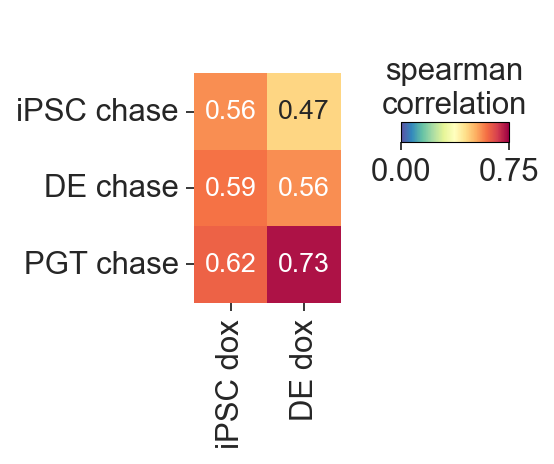

In [10]:
corr_counts = deg_counts[["iPSC_dox", "DE_dox", "iPSC_chase", "DE_chase", "PGT_chase"]]
corr_counts.columns = ["iPSC dox", "DE dox", "iPSC chase", "DE chase", "PGT chase"]

# Correlation
corr_matrix = corr_counts.corr(method="spearman")
corr_matrix = corr_matrix.loc[["iPSC chase", "DE chase", "PGT chase"], ["iPSC dox", "DE dox"]]

# Heatmap
g = sns.clustermap(corr_matrix, cmap="Spectral_r", annot=True, annot_kws={"size": 12}, fmt=".2f",
                   cbar_kws={"shrink": .8, "label": "spearman\ncorrelation", "orientation": "horizontal"}, 
                   cbar_pos=(0.65, 0.6, 0.25, 0.05), vmin=0, vmax=0.75,
                   figsize=(2.7, 2.5), row_cluster=False, col_cluster=False)

# Ticks on left and bottom
g.ax_heatmap.tick_params(left=True, bottom=True, right=False, top=False,
                         labelleft=True, labelbottom=True, labelright=False, labeltop=False)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90)

# Tweak color bar
g.cax.xaxis.set_label_position("top")
g.cax.set_xticks([0, 0.75])
for spine in g.cax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.5)

plt.savefig(f"{output_dir}/Figure2h.svg", format="svg")
plt.show()

## Figure S5f: Correlation DCM dox on scRNA-seq layout

In [11]:
# Add counts per cell
sc_counts = adata.to_df().T
cell_counts = pd.merge(sc_counts, deg_counts, left_index=True, right_index=True)
display(cell_counts)

,AAACAGGC-iPSC,AAAGCGGA-iPSC,AAAGGCTG-iPSC,AACACGCA-iPSC,AACATGGG-iPSC,AACCCAAC-iPSC,AACCGCTT-iPSC,AACCGGAA-iPSC,AACCTGCT-iPSC,AACGAGGT-iPSC,...,NrSites,GeneID,GeneName_y,iPSCs.dox.1,iPSCs.dox.2,iPSCs.dox.3,iPSCs.nodox.1,iPSCs.nodox.2,iPSCs.nodox.3,RNA
LINC01128,0.000000,0.572125,0.000000,0.00000,0.000000,0.000000,0.000000,0.534198,0.000000,0.000000,...,161,ENSG00000228794,LINC01128,1.473668,1.584444,1.570411,1.616136,1.630572,1.621748,1.582830
SAMD11,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,208,ENSG00000187634,SAMD11,0.085145,0.298690,0.265086,0.251008,0.111407,0.361961,0.228883
NOC2L,1.374173,1.581069,0.661965,1.39702,1.304401,1.540214,1.557891,1.137268,1.417915,1.265040,...,157,ENSG00000188976,NOC2L,120.208414,106.318941,121.639989,116.305200,138.038932,188.704053,131.869255
AGRN,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.613966,...,368,ENSG00000188157,AGRN,63.701504,55.507342,67.470402,44.459017,53.673446,49.256110,55.677970
ACAP3,0.000000,0.000000,0.000000,0.00000,0.513644,0.000000,0.000000,0.000000,0.000000,0.613966,...,198,ENSG00000131584,ACAP3,19.460370,17.484355,21.846964,15.910230,15.249250,20.564452,18.419270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F8A1,0.552707,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.534198,0.000000,0.613966,...,15,ENSG00000288722,F8A1,2.965395,2.798392,3.563365,2.366270,3.630469,5.181529,3.417570
BRCC3,0.552707,0.000000,0.000000,0.00000,0.000000,0.000000,0.661243,0.000000,0.000000,0.000000,...,110,ENSG00000185515,BRCC3,38.203880,40.475147,33.534476,45.929253,39.686806,37.953503,39.297177
ZFY,0.000000,0.572125,0.661965,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,120,ENSG00000067646,ZFY,6.168622,4.933416,4.875924,6.272628,6.161523,4.503241,5.485892
NLGN4Y,0.552707,0.000000,0.000000,0.00000,0.000000,0.000000,0.661243,0.000000,0.714338,0.000000,...,795,ENSG00000165246,NLGN4Y,14.458198,14.380909,13.234889,16.469498,15.559735,12.828730,14.488660


In [12]:
corr_samples = ["iPSC_nodox", "iPSC_dox", "DE_dox"]
corr_labels = ["iPSC -dox", "iPSC dox", "DE dox"]

# Calculate correlation per cell
corr_dict = {}
for dcm_sample in corr_samples:
    corrs = []
    for cell in sc_counts.columns:
        corr = cell_counts[dcm_sample].corr(cell_counts[cell], method="spearman")
        corrs.append(corr)
    corr_dict[dcm_sample] = corrs 
corr_df = pd.DataFrame.from_dict(corr_dict, orient="index", columns=sc_counts.columns)
display(corr_df)

for dcm_sample, dcm_label in zip(corr_samples, corr_labels):
    adata.obs[dcm_label] = corr_df.T[dcm_sample]

,AAACAGGC-iPSC,AAAGCGGA-iPSC,AAAGGCTG-iPSC,AACACGCA-iPSC,AACATGGG-iPSC,AACCCAAC-iPSC,AACCGCTT-iPSC,AACCGGAA-iPSC,AACCTGCT-iPSC,AACGAGGT-iPSC,...,TTCGCTGT-PGT,TTCGGAAA-PGT,TTCTCGGA-PGT,TTGATGGC-PGT,TTGCAACC-PGT,TTGTCCAC-PGT,TTGTTCCG-PGT,TTTGAGGG-PGT,TTTGTGTC-PGT,TTTTCGCC-PGT
iPSC_nodox,0.013871,0.022196,-0.013913,-0.010629,0.039487,0.011969,-0.014632,-0.015361,-0.006903,0.019796,...,-0.009013,-0.028648,-0.024198,-0.035935,-0.017325,-0.053950,-0.023307,-0.016333,-0.022301,-0.041056
iPSC_dox,0.378036,0.368065,0.335396,0.339704,0.397068,0.354432,0.357235,0.350819,0.351842,0.355468,...,0.192586,0.167200,0.157542,0.191951,0.196257,0.157874,0.154741,0.173776,0.134625,0.160103
DE_dox,0.151929,0.143444,0.097198,0.127335,0.136447,0.124024,0.119621,0.117599,0.124059,0.111697,...,0.158549,0.123700,0.124718,0.133141,0.142268,0.118272,0.135971,0.125601,0.145795,0.115793


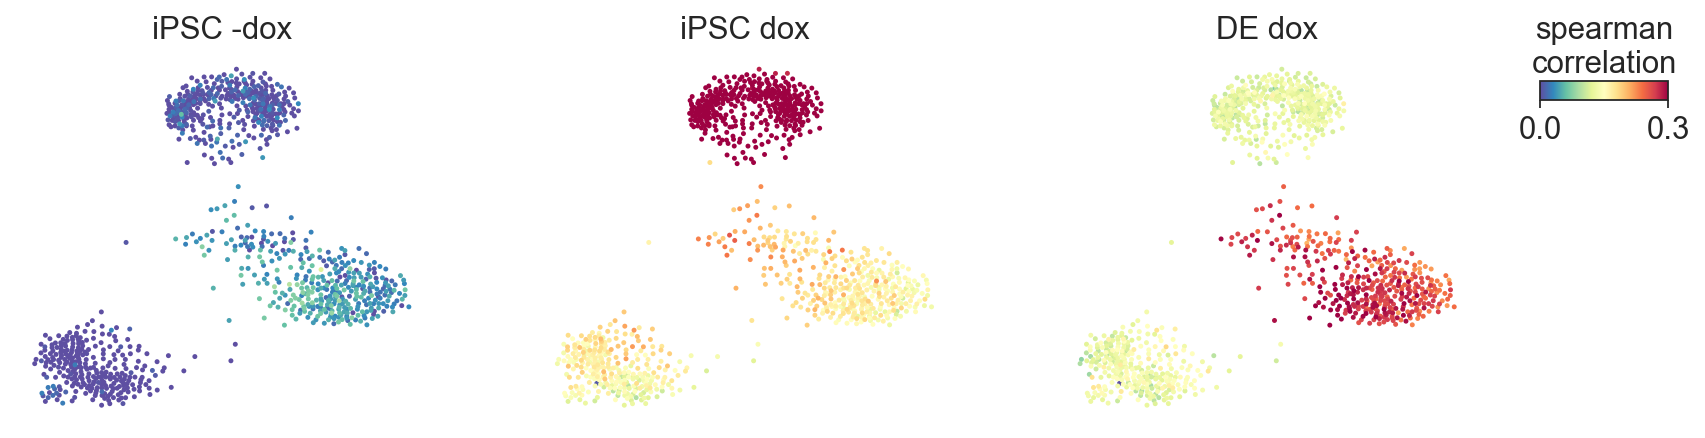

In [13]:
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc_fig = sc.pl.embedding(adata, basis="Harmony", color=corr_labels, ncols=3, cmap="Spectral_r", s=20, 
                             vmin=0, vmax=0.3, frameon=False, show=False, colorbar_loc=None)
    
    cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=0.3), cmap="Spectral_r"), 
                        cax=plt.gcf().add_axes([0.9, 0.8, 0.07, 0.04]), orientation="horizontal")
    cbar.set_label("spearman\ncorrelation")
    cbar.set_ticks([0, 0.3])
    cbar.ax.xaxis.set_label_position("top")
    
    plt.savefig(f"{output_dir}/SupplementalFigure5f.svg", format="svg")
    plt.show()

## Figure S5g: Correlation DCM chase on scRNA-seq layout

In [14]:
corr_samples = ["iPSC_chase", "DE_chase", "PGT_chase"]
corr_labels = ["iPSC chase", "DE chase", "PGT chase"]

# Calculate correlation per cell
corr_dict = {}
for dcm_sample in corr_samples:
    corrs = []
    for cell in sc_counts.columns:
        corr = cell_counts[dcm_sample].corr(cell_counts[cell], method="spearman")
        corrs.append(corr)
    corr_dict[dcm_sample] = corrs 
corr_df = pd.DataFrame.from_dict(corr_dict, orient="index", columns=sc_counts.columns)
display(corr_df)

for dcm_sample, dcm_label in zip(corr_samples, corr_labels):
    adata.obs[dcm_label] = corr_df.T[dcm_sample]

,AAACAGGC-iPSC,AAAGCGGA-iPSC,AAAGGCTG-iPSC,AACACGCA-iPSC,AACATGGG-iPSC,AACCCAAC-iPSC,AACCGCTT-iPSC,AACCGGAA-iPSC,AACCTGCT-iPSC,AACGAGGT-iPSC,...,TTCGCTGT-PGT,TTCGGAAA-PGT,TTCTCGGA-PGT,TTGATGGC-PGT,TTGCAACC-PGT,TTGTCCAC-PGT,TTGTTCCG-PGT,TTTGAGGG-PGT,TTTGTGTC-PGT,TTTTCGCC-PGT
iPSC_chase,0.115811,0.120549,0.076833,0.086593,0.135834,0.092781,0.083962,0.081734,0.087000,0.111961,...,0.044070,0.021106,0.018014,0.016606,0.025536,-0.007410,0.028291,0.027858,0.014702,0.001101
DE_chase,0.101512,0.090235,0.049962,0.068089,0.105582,0.080457,0.063092,0.054439,0.065204,0.086457,...,0.040827,0.007981,0.010071,0.006672,0.022402,-0.013936,0.023420,0.016798,0.019330,-0.016424
PGT_chase,0.092924,0.078468,0.033800,0.056846,0.086735,0.057307,0.049597,0.041536,0.045593,0.064354,...,0.103665,0.074624,0.069173,0.074283,0.089964,0.048535,0.084886,0.080406,0.086582,0.055141


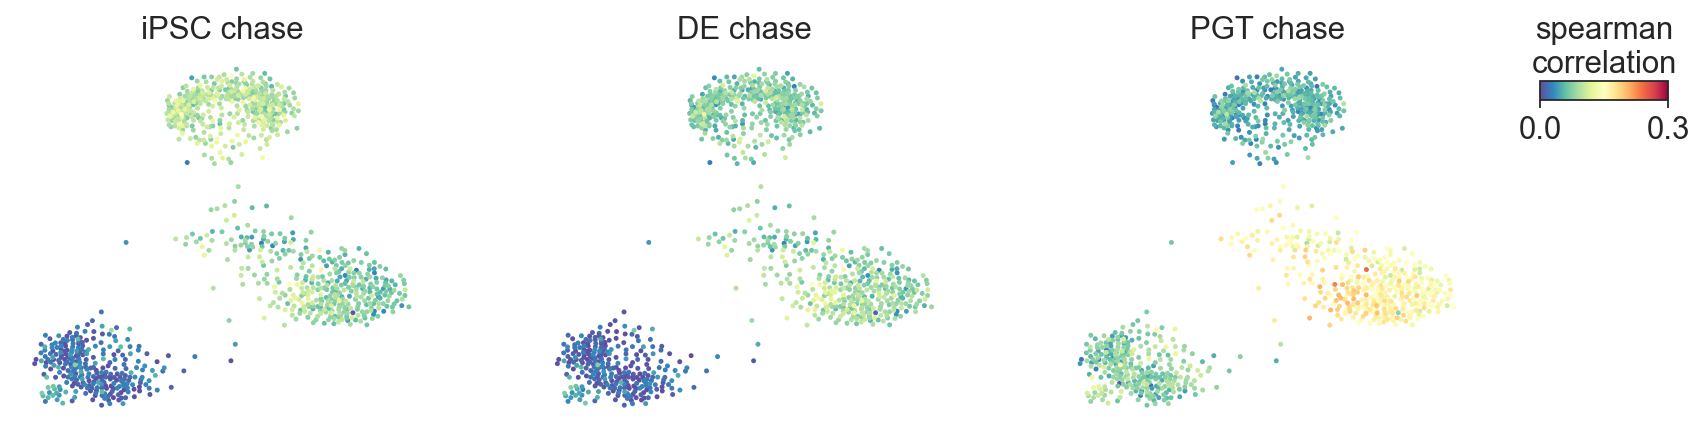

In [15]:
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc_fig = sc.pl.embedding(adata, basis="Harmony", color=corr_labels, ncols=3, cmap="Spectral_r", s=20, 
                             vmin=0, vmax=0.3, frameon=False, show=False, colorbar_loc=None)
    
    cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=0.3), cmap="Spectral_r"), 
                        cax=plt.gcf().add_axes([0.9, 0.8, 0.07, 0.04]), orientation="horizontal")
    cbar.set_label("spearman\ncorrelation")
    cbar.set_ticks([0, 0.3])
    cbar.ax.xaxis.set_label_position("top")

    plt.tight_layout()
    plt.savefig(f"{output_dir}/SupplementalFigure5g.svg", format="svg")
    plt.show()